# 1. IMPORT LIBRARIES

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# 2. LOAD DATASET

In [9]:
df=pd.read_csv("Housing_Price.csv")
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


# 3. BASIC DATA EXPLORATION

In [10]:
print("Column Names:")
print(df.columns.tolist())
print("\nDataset Information:")
df.info()
print("\nDescriptive Statistics:")
display(df.describe())

Column Names:
['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB

Descriptive Statistics:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


# 4. CHECK MISSING VALUES

In [44]:
missing_values = df.isnull().sum()
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})
missing_table = missing_table[
    missing_table["Missing Count"] > 0
]
display(
    missing_table.sort_values(
        by="Missing Percentage",
        ascending=False
    )
)

,Missing Count,Missing Percentage


# 5. DEFINE TARGET VARIABLE

In [19]:
# Target variable
target = "Price"
print("Target Variable:", target)

Target Variable: Price


# 6. TARGET DISTRIBUTION

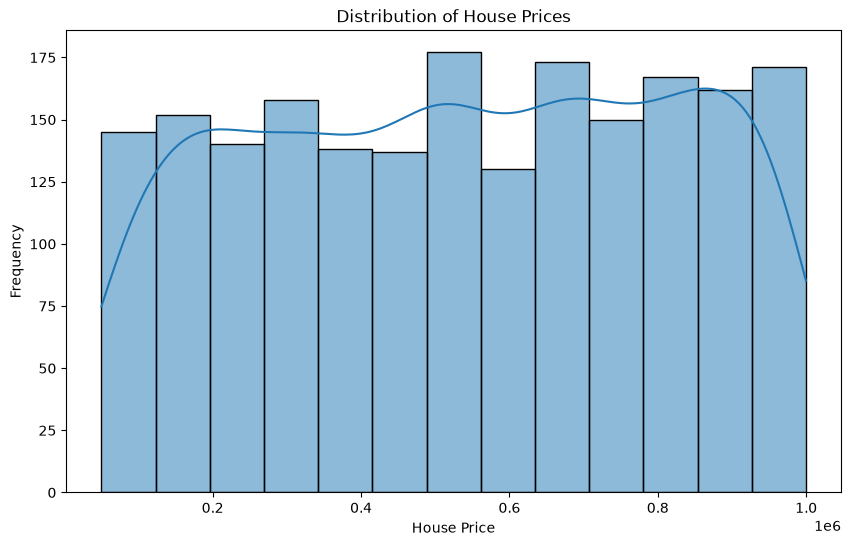

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(df[target], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

# 7. FEATURE SELECTION

In [21]:
# Select features
features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt",
    "Location",
    "Condition",
    "Garage"
]
X = df[features]
y = df[target]
print("Selected Features:")
print(features)

Selected Features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage']


# 8. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES

In [22]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()
print("\nNumerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

Categorical Features:
['Location', 'Condition', 'Garage']


# 9. CORRELATION HEATMAP

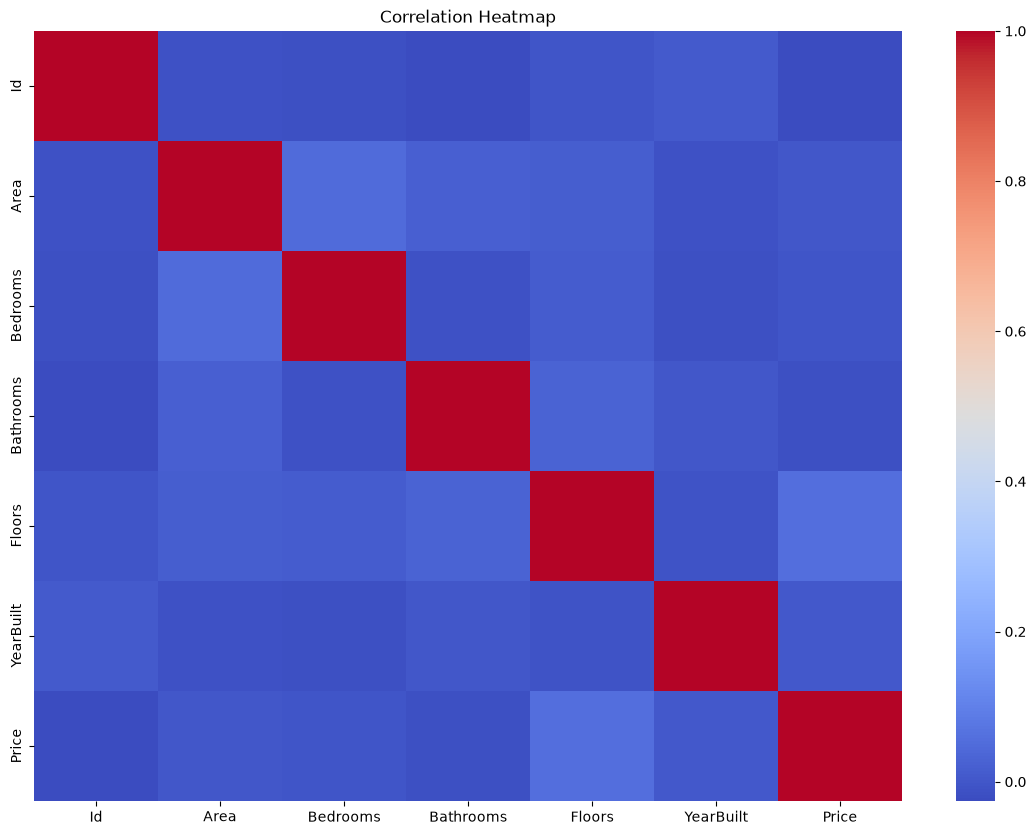

In [23]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)
correlation = numeric_df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()

# 10. CORRELATION WITH HOUSE PRICE

In [24]:
price_correlation = correlation[target].sort_values(
    ascending=False
)
print("Features most correlated with house price:")
display(price_correlation.head(10))

Features most correlated with house price:


Price        1.000000
Floors       0.055890
YearBuilt    0.004845
Area         0.001542
Bedrooms    -0.003471
Bathrooms   -0.015737
Id          -0.025643
Name: Price, dtype: float64

# 11. PREPROCESSING

In [27]:
numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# 12. COMBINE PREPROCESSING

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# 13. TRAIN-TEST SPLIT

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1600
Testing samples: 400


# 14. LINEAR REGRESSION MODEL

In [51]:
linear_regression = LinearRegression()
model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regressor",
            linear_regression
        )
    ]
)

# 15. TRAIN MODEL

In [52]:
model.fit(
    X_train,
    y_train
)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


# 16. MAKE PREDICTIONS

In [53]:
y_pred = model.predict(X_test)
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[521988.22189839 549119.31196651 487101.22235594 539752.7439933
 553242.24872512 521375.92025826 523320.18080583 578133.64353335
 545899.64738458 577368.69940644]


# 17. MODEL EVALUATION

In [33]:
mse = mean_squared_error(
    y_test,
    y_pred
)
rmse = np.sqrt(mse)
r2 = r2_score(
    y_test,
    y_pred
)
print("\nLinear Regression Performance")
print("--------------------------------")
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)


Linear Regression Performance
--------------------------------
MSE  : 78321466146.0328
RMSE : 279859.72583784326
R²   : -0.006717808430749761


# 18. ACTUAL VS PREDICTED PRICES

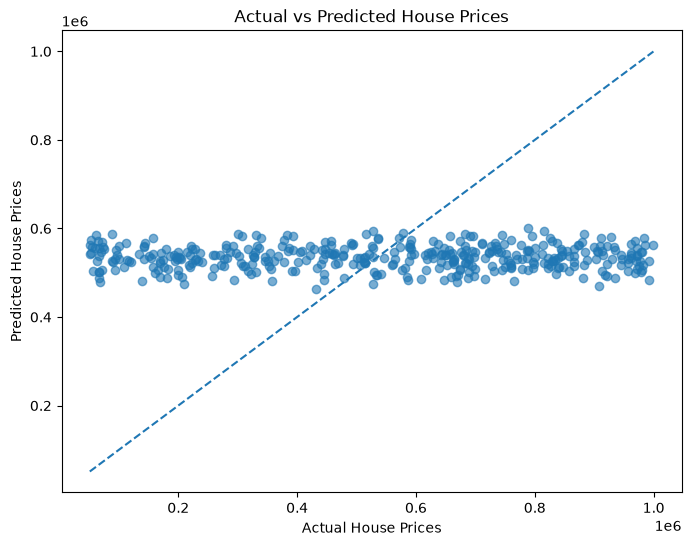

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)
minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# 19. RESIDUAL ANALYSIS

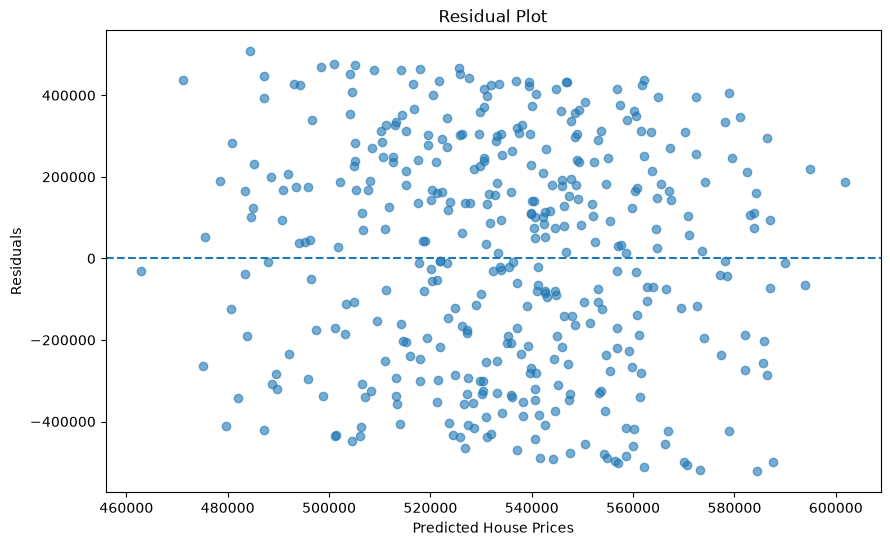

In [35]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


# 20. COEFFICIENT ANALYSIS

In [36]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()coefficients = model.named_steps[
    "regressor"
].coef_
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)
print("Top Positive Coefficients:")
display(coefficient_df.head(10))
print("Top Negative Coefficients:")
display(coefficient_df.tail(10))

Top Positive Coefficients:


,Feature,Coefficient
3,num__Floors,23727.983633
10,cat__Condition_Fair,20279.424861
7,cat__Location_Suburban,11484.336584
6,cat__Location_Rural,1289.888789
14,cat__Garage_Yes,1186.765289
12,cat__Condition_Poor,269.385945
4,num__YearBuilt,117.613885
1,num__Bedrooms,76.784827
0,num__Area,-0.575754
5,cat__Location_Downtown,-27.653231


Top Negative Coefficients:


,Feature,Coefficient
12,cat__Condition_Poor,269.385945
4,num__YearBuilt,117.613885
1,num__Bedrooms,76.784827
0,num__Area,-0.575754
5,cat__Location_Downtown,-27.653231
13,cat__Garage_No,-1186.765289
9,cat__Condition_Excellent,-3803.882985
2,num__Bathrooms,-9662.248234
8,cat__Location_Urban,-12746.572142
11,cat__Condition_Good,-16744.927821


# 21. POSITIVE COEFFICIENT PLOT

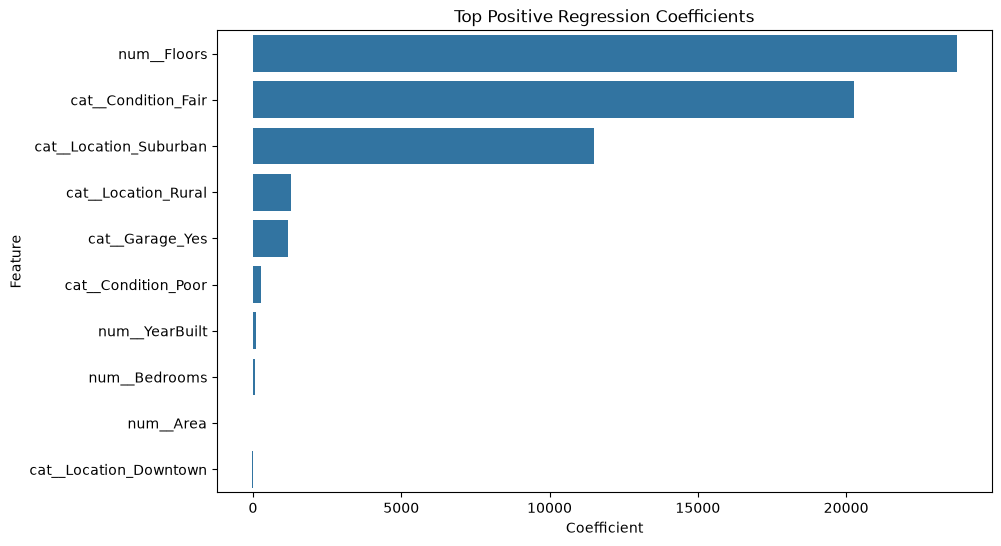

In [37]:
top_positive = coefficient_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Positive Regression Coefficients")

plt.show()

# 22. NEGATIVE COEFFICIENT PLOT

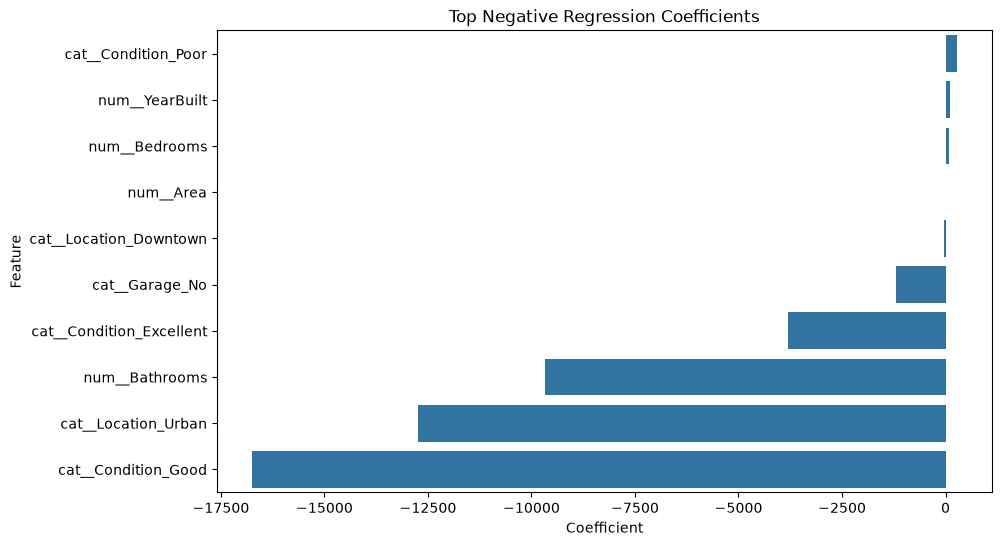

In [38]:
top_negative = coefficient_df.tail(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Feature"
)
plt.title("Top Negative Regression Coefficients")
plt.show()

# 23. BONUS - RIDGE REGRESSION

In [54]:
ridge_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regressor",
            Ridge(alpha=1.0)
        )
    ]
)

ridge_model.fit(
    X_train,
    y_train
)

ridge_pred = ridge_model.predict(
    X_test
)

# 24. RIDGE EVALUATION

In [40]:
ridge_mse = mean_squared_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    ridge_mse
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print("\nRidge Regression Performance")
print("--------------------------------")
print("MSE  :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R²   :", ridge_r2)


Ridge Regression Performance
--------------------------------
MSE  : 78321066392.83418
RMSE : 279859.0116341337
R²   : -0.006712670137458687


# 25. MODEL COMPARISON

In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R2 Score": [
        r2,
        ridge_r2
    ]
})

display(comparison)

,Model,MSE,RMSE,R2 Score
0,Linear Regression,7.832147e+10,279859.725838,-0.006718
1,Ridge Regression,7.832107e+10,279859.011634,-0.006713


# final conclusion

In [42]:
print("FINAL MODEL RESULTS")
print("----------------------------")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

FINAL MODEL RESULTS
----------------------------
MSE  : 78,321,466,146.03
RMSE : 279,859.73
R²   : -0.0067
